# GNN Class Separability and Feature Analysis

This notebook assesses GNN class separability and reduces confusion in forest type classes using Linear Discriminant Analysis (LDA), Jeffries-Matusita (JM) distance, and Hierarchical Clustering.

## 1. Data Loading and Preprocessing

Initialize dataset environment and loads the tabular data containing spectral features and class labels. Align column names and map GNN classes to ODF forest types.

In [1]:
%load_ext cudf.pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from forestvision.datasets import GNNForestAttr

# Set plot style
plt.style.use('ggplot')

# Set global random state for reproducibility
random_state = None
np.random.seed(random_state)

In [3]:
# Initialize GNN dataset for remapping information
paths = "../data/datasets/gnn/2021/"
gnn = GNNForestAttr(paths=paths, remap=False, res=10, crs="EPSG:5070")
gnn.is_image = True 

# Load data
COLNAMES = [
    'label', 
    'oB1', 'oB2', 'oB3', 'oB4', 'oB5', 'oB6', 'oB7', 'oB8', 'oB8A', 'oB9', 'oB11', 'oB12', 
    'oNDVI', 'oNBR', 'oEVI', 'oSAVI', 'oNIRv', 
    'fB1', 'fB2', 'fB3', 'fB4', 'fB5', 'fB6', 'fB7', 'fB8', 'fB8A', 'fB9', 'fB11', 'fB12', 
    'fNDVI', 'fNBR', 'fEVI', 'fSAVI', 'fNIRv', 
    'DEM', 'AHM', 'MAP', 'TD', 'centroid'
]
SELCOLS = [
        'label',
        'oB2', 'oB3', 'oB4', 'oB5','oNDVI', 'oNBR', 'oSAVI', 'oNIRv',
        'fNDVI', 'fSAVI',
        'DEM', 'AHM', 'MAP', 'TD','centroid'
    ]
data = pd.read_csv('../data/fortypba/data_table.csv')#, header=0)
data.columns = COLNAMES
# data = data.drop(data[data.label == '# gnn'].index)
data['label'] = data.label.astype(float).astype(int)

# # Map to ODF labels
data.insert(1, 'odf', data.label.replace(gnn.remap_dict))

# # Filter for specific ODF classes
odf = [9,10,11]
subset = data[data.odf.isin(odf)][data.columns].copy()
del data

subset['weight'] = 1.0 / subset.odf.map(subset.odf.value_counts())
subset = subset.sample(n=3000000, random_state=random_state, weights='weight')
subset.reset_index(drop=True, inplace=True)
print("Subset preview:", subset['odf'].value_counts())
print(f"Subset shape: {subset.shape}")
subset.drop(columns=['odf','weight'], inplace=True)
if SELCOLS:
    print(f"Using columns: {SELCOLS}")
    subset = subset[SELCOLS]

# Clean data: Replace infinity with NaN and drop rows with any NaN
initial_len = len(subset)
subset.replace([np.inf, -np.inf], np.nan, inplace=True)
subset.dropna(inplace=True)
dropped = initial_len - len(subset)
if dropped > 0:
    print(f"Dropped {dropped} rows containing Inf or NaN values.")

# Check for extremely large values that could still cause issues
numeric_cols = subset.select_dtypes(include=[np.number]).columns
if not subset.empty:
    max_val = subset[numeric_cols].max().max()
    if max_val > 1e15:
        print(f"Warning: Extremely large values detected (max={max_val}). Clipping to 1e15.")
        subset[numeric_cols] = subset[numeric_cols].clip(lower=-1e15, upper=1e15)

subset.head()

Subset preview: odf
11    1125589
9     1037804
10     836607
Name: count, dtype: int64
Subset shape: (3000000, 42)
Using columns: ['label', 'oB2', 'oB3', 'oB4', 'oB5', 'oNDVI', 'oNBR', 'oSAVI', 'oNIRv', 'fNDVI', 'fSAVI', 'DEM', 'AHM', 'MAP', 'TD', 'centroid']


,label,oB2,oB3,oB4,oB5,oNDVI,oNBR,oSAVI,oNIRv,fNDVI,fSAVI,DEM,AHM,MAP,TD,centroid
0,669.0,227.0,464.0,280.5,862.0,0.850897,0.609615,1.276176,2962.823486,0.703117,1.054502,509.977112,137.0,1608.0,175.0,1.000000e+15
1,608.0,186.0,450.0,190.0,836.5,0.901554,0.789371,1.352156,3308.704590,0.923546,1.385097,85.132530,137.0,1595.0,115.0,1.000000e+15
2,425.0,222.0,467.0,216.0,781.0,0.892884,0.737765,1.339159,3408.137207,0.917392,1.375833,155.003418,142.0,1454.0,140.0,1.000000e+15
3,198.0,282.0,610.0,306.0,1156.0,0.892613,0.694314,1.338802,4813.860352,0.761523,1.142121,227.476669,125.0,1682.0,140.0,1.000000e+15
4,653.0,208.0,374.0,183.0,738.0,0.909874,0.740379,1.364644,3528.493164,0.874679,1.311759,81.653831,85.0,2432.0,110.0,1.000000e+15


## 2. Linear Discriminant Analysis (LDA)

### Methodology
LDA is a dimensionality reduction technique that maximizes the ratio of between-class variance to within-class variance. We use it to identify which spectral bands are most influential in distinguishing between forest types.

### Goal
Understand feature importance and project data into a lower-dimensional space that maximizes separability.

### Steps
1. Standardize features.
2. Fit the LDA model to the subset data.
3. Analyze explained variance and component loadings (scalings).
4. Project data onto the linear discriminants.

In [4]:
%load_ext cuml.accel

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def perform_lda_analysis(df: pd.DataFrame, class_label: str, n_components: int = 3) -> None:
    """
    Performs LDA on the given dataset and plots the results in 2D.

    Args:
        df (pd.DataFrame): The DataFrame containing pixel data.
        class_label (str): The name of the column containing class labels.
    """
    try:
        # Separate features (X) and target (y)
        X = df.drop(class_label, axis=1)
        y = df[class_label]
        unique_labels = sorted(y.unique())

        # Standardize the features (important for LDA)
        X_scaled = StandardScaler().fit_transform(X)

        # --- Perform LDA ---
        # We set n_components=5 to project the data into a 5D space for plotting
        lda = LinearDiscriminantAnalysis(n_components=n_components)
        X_lda = lda.fit_transform(X_scaled, y)
        
        # Create a DataFrame for plotting LDA results
        lda_df = pd.DataFrame(X_lda, columns=[f'LD{i+1}' for i in range(X_lda.shape[1])])
        lda_df[class_label] = y.values

        print(f"Explained variance ratio of the {n_components} linear discriminants: {lda.explained_variance_ratio_}")
 
       # --- 1. Explained Variance Ratio ---
        print("\n1. Explained Variance Ratio:")
        print("This shows the proportion of the inter-class variance explained by each discriminant.")
        for i, ratio in enumerate(lda.explained_variance_ratio_):
            print(f"  - Linear Discriminant {i+1} (LD{i+1}): {ratio:.2%}")
            
        # --- 2. Component Loadings (Coefficients) ---
        print("\n2. LDA Component Loadings (Scalings):")
        print("This table shows the weight of each spectral band on the discriminant axes.")
        print("A high absolute value means the band is highly influential for that axis.")
        
        loadings_df = pd.DataFrame(
            lda.scalings_,
            index=X.columns,
            columns=[f'LD{i+1}' for i in range(len(lda.scalings_[0]))]
        )
        print(loadings_df[loadings_df.columns[:5]].round(4))
        
        # --- Interpretation Helper ---
        print("\n--- Interpretation ---")
        for i in range(min(5, len(unique_labels) - 1)):
            ld_name = f'LD{i+1}'
            # Get the band with the highest absolute loading for this component
            most_influential_band = loadings_df[ld_name].abs().idxmax()
            print(f"For {ld_name}, the most influential band is '{most_influential_band}'.")
        
        # Visualize the LDA separation
        # sns.scatterplot(data=lda_df, x='LD1', y='LD2', palette='viridis', hue=class_label, s=100)
        # plt.title("Sites Projected onto LDA Axes")
        # plt.show()

    except FileNotFoundError:
        print(f"Error: The file '{df}' was not found.")
    except KeyError:
        print(f"Error: The CSV must contain a '{class_label}' column.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    finally:
        plt.close()
        return lda, lda_df

In [6]:
subset

,label,oB2,oB3,oB4,oB5,oNDVI,oNBR,oSAVI,oNIRv,fNDVI,fSAVI,DEM,AHM,MAP,TD,centroid
0,669.0,227.0,464.0,280.5,862.0,0.850897,0.609615,1.276176,2962.823486,0.703117,1.054502,509.977112,137.0,1608.0,175.0,1.000000e+15
1,608.0,186.0,450.0,190.0,836.5,0.901554,0.789371,1.352156,3308.704590,0.923546,1.385097,85.132530,137.0,1595.0,115.0,1.000000e+15
2,425.0,222.0,467.0,216.0,781.0,0.892884,0.737765,1.339159,3408.137207,0.917392,1.375833,155.003418,142.0,1454.0,140.0,1.000000e+15
3,198.0,282.0,610.0,306.0,1156.0,0.892613,0.694314,1.338802,4813.860352,0.761523,1.142121,227.476669,125.0,1682.0,140.0,1.000000e+15
4,653.0,208.0,374.0,183.0,738.0,0.909874,0.740379,1.364644,3528.493164,0.874679,1.311759,81.653831,85.0,2432.0,110.0,1.000000e+15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,192.0,239.5,560.0,272.5,1012.0,0.865382,0.754239,1.297913,3267.683350,0.877710,1.316382,428.522858,280.0,801.0,183.0,1.000000e+15
2999996,669.0,271.0,506.0,251.0,977.0,0.887896,0.738791,1.331696,3753.137939,0.883847,1.325591,58.752449,112.0,1886.0,98.0,1.000000e+15
2999997,624.0,109.0,251.0,136.5,596.5,0.875541,0.683650,1.313013,1800.988647,0.910728,1.365558,181.081024,53.0,3775.0,141.0,1.000000e+15
2999998,126.0,233.0,460.0,235.0,920.0,0.861234,0.601219,1.291661,2714.609863,0.786854,1.179904,112.357689,160.0,1297.0,141.0,1.000000e+15


In [7]:
lda, lda_res = perform_lda_analysis(subset, class_label='label', n_components=7);

Explained variance ratio of the 7 linear discriminants: [0.37648662 0.23851086 0.17093213 0.09128932 0.05349228 0.02650337
 0.01347913]

1. Explained Variance Ratio:
This shows the proportion of the inter-class variance explained by each discriminant.
  - Linear Discriminant 1 (LD1): 37.65%
  - Linear Discriminant 2 (LD2): 23.85%
  - Linear Discriminant 3 (LD3): 17.09%
  - Linear Discriminant 4 (LD4): 9.13%
  - Linear Discriminant 5 (LD5): 5.35%
  - Linear Discriminant 6 (LD6): 2.65%
  - Linear Discriminant 7 (LD7): 1.35%

2. LDA Component Loadings (Scalings):
This table shows the weight of each spectral band on the discriminant axes.
A high absolute value means the band is highly influential for that axis.
              LD1      LD2      LD3      LD4      LD5
oB2        0.2051  -1.2403   0.0019  -0.0904   0.3372
oB3        0.4376   0.7821   0.0012  -0.3302  -0.4925
oB4       -1.2235   0.0076  -0.5142   0.9331   0.0198
oB5        0.1252   0.6878   0.3723  -0.4630   0.2621
oNDVI     60.

## 3. Jeffries-Matusita (JM) Distance Matrix

### Methodology
The JM distance is a parametric measure of separability between two classes. It ranges from 0 (identical distributions) to 2 (complete separability). We use it to identify specific class pairs that are highly confused.

### Goal
Quantify class separability using a statistical metric.

### Steps
1. Compute class-wise statistics (mean and covariance).
2. Calculate pairwise JM distances for all classes.
3. Identify the most similar (confused) classes.

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
import warnings
from typing import Dict, Tuple, List, Callable


def compute_class_statistics(
    df: pd.DataFrame,
    class_column: str = 'class'
) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """
    Compute mean vector and covariance matrix for each class in the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with feature columns and a class label column.
            Shape: [N_samples, N_features + 1] where +1 is the class column.
        class_column (str): Name of the column containing class labels.

    Returns:
        Dict[str, Tuple[np.ndarray, np.ndarray]]: Dictionary mapping class labels
            to tuples of (mean, covariance) where:
            - mean: ndarray of shape [N_features]
            - covariance: ndarray of shape [N_features, N_features]

    Raises:
        ValueError: If class_column not found or no feature columns present.
    """
    if class_column not in df.columns:
        raise ValueError(f"Class column '{class_column}' not found in DataFrame. "
                        f"Available columns: {list(df.columns)}")

    feature_columns = [col for col in df.columns if col != class_column]
    if len(feature_columns) == 0:
        raise ValueError("No feature columns found in DataFrame.")

    class_stats = {}
    for label, group in df.groupby(class_column):
        n_samples = len(group)
        if n_samples < 2:
            warnings.warn(f"Class '{label}' has only {n_samples} sample(s). "
                         "Covariance will be regularized.")

        features = group[feature_columns].values
        mean = np.mean(features, axis=0)
        
        if n_samples >= 2:
            cov = np.cov(features, rowvar=False)
        else:
            cov = np.eye(len(feature_columns)) * 1e-3

        class_stats[label] = (mean, cov)

    return class_stats


def jeffries_matusita_metric(
    df: pd.DataFrame,
    class_column: str = 'class'
) -> Callable[[int, int], float]:
    """
    Create a custom JM distance metric function for use with pairwise_distances.

    Args:
        df (pd.DataFrame): Raw samples with feature columns and a class column.
            Shape: [N_samples, N_features + 1]
        class_column (str): Name of the column containing class labels.

    Returns:
        Callable[[int, int], float]: A metric function that takes indices i, j
            and returns JM distance in range [0, 2].
    """
    class_stats_dict = compute_class_statistics(df, class_column)

    class_labels = sorted(class_stats_dict.keys())
    means = [class_stats_dict[label][0] for label in class_labels]
    covs = [class_stats_dict[label][1] for label in class_labels]

    stats_lookup = {i: (means[i], covs[i]) for i in range(len(class_labels))}

    def jm_metric(i: int, j: int) -> float:
        """
        Compute JM distance between classes at indices i and j.

        Args:
            i (int): Index of first class.
            j (int): Index of second class.

        Returns:
            float: JM distance in range [0, 2].
        """
        mean1, cov1 = stats_lookup[i]
        mean2, cov2 = stats_lookup[j]

        if i == j:
            return 0.0

        n_features = len(mean1)
        cov1_reg = cov1 + np.eye(n_features) * 1e-6
        cov2_reg = cov2 + np.eye(n_features) * 1e-6

        pooled_cov = (cov1_reg + cov2_reg) / 2
        diff = mean1 - mean2

        try:
            inv_pooled_cov = np.linalg.inv(pooled_cov)
        except np.linalg.LinAlgError:
            inv_pooled_cov = np.linalg.pinv(pooled_cov)

        term1 = 0.125 * diff.T @ inv_pooled_cov @ diff

        det_cov1 = np.linalg.det(cov1_reg)
        det_cov2 = np.linalg.det(cov2_reg)
        det_pooled = np.linalg.det(pooled_cov)
        # det_sum = np.linalg.det(cov1_reg + cov2_reg)

        if det_cov1 <= 0 or det_cov2 <= 0 or det_pooled <= 0:
            warnings.warn("Non-positive determinant encountered. Using stronger regularization.")
            cov1_reg = cov1 + np.eye(n_features) * 1e-3
            cov2_reg = cov2 + np.eye(n_features) * 1e-3
            det_cov1 = np.linalg.det(cov1_reg)
            det_cov2 = np.linalg.det(cov2_reg)
            det_pooled = np.linalg.det(pooled_cov)

        term2 = 0.5 * np.log(det_pooled / (np.sqrt(det_cov1) * np.sqrt(det_cov2)))

        B = term1 + term2
        JM = 2 * (1 - np.exp(-B))

        return np.clip(JM, 0, 2)

    return jm_metric


def compute_jm_matrix_with_sklearn(
    df: pd.DataFrame,
    class_column: str = 'class'
) -> Tuple[np.ndarray, List]:
    """
    Compute JM distance matrix using sklearn's pairwise_distances approach.

    Args:
        df (pd.DataFrame): Raw samples with feature columns and a class column.
            Shape: [N_samples, N_features + 1]
        class_column (str): Name of the column containing class labels.

    Returns:
        Tuple[np.ndarray, List]:
            - jm_matrix: Symmetric distance matrix of shape [N_classes, N_classes].
              Values range from 0 (identical) to 2 (completely separable).
            - class_labels: Sorted list of class labels corresponding to matrix indices.

    Example:
        >>> df = pd.DataFrame({
        ...     'band1': [0.2, 0.3, 0.8, 0.9],
        ...     'band2': [0.1, 0.2, 0.7, 0.8],
        ...     'class': ['oak', 'oak', 'pine', 'pine']
        ... })
        >>> jm_matrix, labels = compute_jm_matrix_with_sklearn(df)
        >>> print(labels)
        ['oak', 'pine']
    """
    class_stats_dict = compute_class_statistics(df, class_column)

    class_labels = sorted(class_stats_dict.keys())
    n_classes = len(class_labels)

    indices = np.arange(n_classes).reshape(-1, 1)

    jm_metric_func = jeffries_matusita_metric(df, class_column)

    def metric_wrapper(x: np.ndarray, y: np.ndarray) -> float:
        """Wrapper to convert array indices to scalar indices."""
        i = int(x[0])
        j = int(y[0])
        return jm_metric_func(i, j)

    jm_matrix = pairwise_distances(indices, metric=metric_wrapper)

    return jm_matrix, class_labels 

In [9]:
from sklearn.preprocessing import StandardScaler

use_lda = True

if use_lda:
    cluster_data = lda_res.copy()
else:
    cluster_data = subset.copy()

    feature_cols = [col for col in cluster_data.columns if col != 'label']
    scaler_subset = StandardScaler()
    cluster_data[feature_cols] = scaler_subset.fit_transform(cluster_data[feature_cols])

In [10]:
jm_matrix, class_labels = compute_jm_matrix_with_sklearn(cluster_data, class_column='label')
jm_df = pd.DataFrame(jm_matrix, index=class_labels, columns=class_labels)
# jm_df.head(20)

/tmp/ipykernel_639787/653215322.py:41: UserWarning: Class '982.0' has only 1 sample(s). Covariance will be regularized.
  warnings.warn(f"Class '{label}' has only {n_samples} sample(s). "


In [11]:
print("\n" + "="*50)
print("JM Distance Matrix")
print("="*50)
print(f"\nClass labels: {class_labels[:10]}\n")
print(jm_df[jm_df.columns[:10]].round(2))
print("\n" + "="*50)

# Find min and max distance pairs
mask = jm_matrix > 0
min_val = jm_matrix[mask].min()
min_indices = np.where(jm_matrix == min_val)
min_pairs = [(class_labels[i], class_labels[j]) for i, j in zip(min_indices[0], min_indices[1])]
print(f"Min JM distance: {min_val:.4f} between classes: {min_pairs[0]}")

max_val = jm_matrix.max()
max_indices = np.where(jm_matrix == max_val)
max_pairs = [(class_labels[i], class_labels[j]) for i, j in zip(min_indices[0], min_indices[1])]
print(f"Max JM distance: {max_val:.4f} between classes: {max_pairs[0]}")



JM Distance Matrix

Class labels: [6.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 42.0, 43.0, 58.0]

       6.0   33.0  34.0  35.0  36.0  37.0  38.0  42.0  43.0  58.0
6.0    0.00  1.72  0.71  1.03  0.74  1.23  1.13  1.15  0.98  1.04
33.0   1.72  0.00  1.49  1.12  1.05  0.96  1.04  0.77  0.88  1.50
34.0   0.71  1.49  0.00  0.80  0.62  1.09  0.83  1.02  0.67  0.74
35.0   1.03  1.12  0.80  0.00  0.28  0.24  0.25  0.32  0.22  0.60
36.0   0.74  1.05  0.62  0.28  0.00  0.38  0.32  0.26  0.16  0.64
...     ...   ...   ...   ...   ...   ...   ...   ...   ...   ...
968.0  1.98  1.93  1.97  1.87  1.91  1.88  1.92  1.88  1.90  1.95
969.0  1.99  1.84  1.97  1.82  1.86  1.83  1.89  1.81  1.84  1.94
975.0  1.99  1.94  1.98  1.90  1.92  1.92  1.95  1.91  1.91  1.96
982.0  2.00  2.00  2.00  2.00  2.00  2.00  2.00  2.00  2.00  2.00
983.0  2.00  1.85  1.99  1.90  1.91  1.86  1.92  1.85  1.89  1.96

[232 rows x 10 columns]

Min JM distance: 0.0303 between classes: (193.0, 581.0)
Max JM distance: 2.0000 betwee

## 4. Hierarchical Clustering

### Methodology
Using the JM distance matrix as a distance metric, we perform hierarchical clustering to group classes that are statistically similar. This helps in remapping GNN classes into more distinct aggregate groups.

### Goal
Identify clusters of confused classes to guide remapping.

### Steps
1. Convert JM matrix to condensed form.
2. Perform hierarchical clustering with complete linkage.
3. Assign classes to a specified number of clusters.
4. Merge cluster labels back to the dataset.

In [12]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# cluster_data = lda_res.copy()

# Extract clusters
n_clusters = 5
cluster = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='complete')
cluster_labels = cluster.fit_predict(jm_matrix)

clustered = pd.DataFrame({'cluster': cluster_labels}, index=class_labels)
cluster_data['cluster'] = cluster_data['label'].replace(clustered['cluster'].to_dict())

print("Cluster Assignments:")
print(cluster_data.head())
print(f"\nUnique clusters in subset: {cluster_data['cluster'].unique()}")

Cluster Assignments:
        LD1       LD2       LD3       LD4       LD5       LD6       LD7  \
0 -0.559214 -0.921456 -0.023085  0.788542  0.818974 -0.493276  0.705295   
1  0.226333 -0.240918  0.345836 -1.039387 -0.463849  0.729863  0.257000   
2 -0.122082 -1.063901  0.256528 -0.597452  0.312559  0.078021  0.421150   
3 -1.123278 -2.131345 -0.618730  0.826015  0.128193  1.151709  0.207013   
4 -0.008839 -1.121966 -1.265115 -0.092836 -0.439428  0.671603 -0.376790   

   label  cluster  
0  669.0      1.0  
1  608.0      1.0  
2  425.0      1.0  
3  198.0      1.0  
4  653.0      1.0  

Unique clusters in subset: [1. 0. 4. 2. 3.]


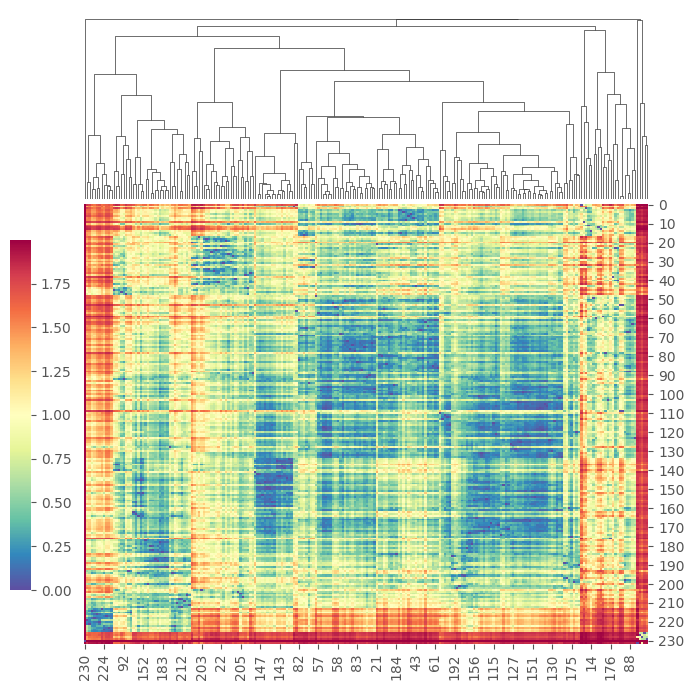

In [13]:
from cudf.pandas.module_accelerator import disable_module_accelerator
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, cut_tree

# Perform hierarchical clustering
jm_condensed = squareform(jm_matrix)
linked = linkage(jm_condensed, method='complete')

# 2. Use the context manager to disable cudf.pandas for the plotting section
with disable_module_accelerator():
    # Plot
    g = sns.clustermap(
        jm_df,
        row_linkage=linked,
        col_linkage=linked,
        cmap='Spectral_r',
        figsize=(7, 7),
        row_cluster=False,
        dendrogram_ratio=(0.1, 0.3),
        cbar_pos=(0.015, .15, .03, .5)
    )
    # g.figure.suptitle('JM Distance Matrix with Hierarchical Clustering', y=1.02, fontsize=12)
    plt.show()

In [31]:
(
    pd.DataFrame(
        {
            'cluster': cut_tree(linked, n_clusters=5).flatten().tolist(), 
            'label': class_labels
        }
    )
).groupby('cluster').size()

cluster
0     23
1    203
2      4
3      1
4      1
dtype: int64

In [15]:
clustered.groupby('cluster').size()

cluster
0     23
1    203
2      4
3      1
4      1
dtype: int64

## 5. Classification and Evaluation

### Methodology
We train a Support Vector Classifier (SVC) on the clustered labels to evaluate how well the newly defined groups can be separated using the features.

### Goal
Assess the classifier performance before and after remapping/clustering.

### Steps
1. Prepare features and target (cluster labels).
2. Split into training and testing sets.
3. Train a LinearSVC.
4. Evaluate with a classification report and accuracy score.

In [16]:
cluster_data['odf'] = cluster_data['label'].replace(gnn.remap_dict)
print(cluster_data.groupby('odf').size())
print(cluster_data.groupby('cluster').size())

odf
9.0     1037804
10.0     836607
11.0    1125589
dtype: int64
cluster
0.0     230855
1.0    2760634
2.0       5498
3.0          1
4.0       3012
dtype: int64


In [17]:
cluster_data.groupby(['cluster', 'odf']).size()

cluster  odf 
0.0      9.0      139815
         10.0      86982
         11.0       4058
1.0      9.0      890650
         10.0     748453
         11.0    1121531
2.0      9.0        4327
         10.0       1171
3.0      10.0          1
4.0      9.0        3012
dtype: int64

In [18]:
target = 200000

In [19]:
balanced_dfs = []
for c in cluster_data['cluster'].unique():
    group = cluster_data[cluster_data['cluster'] == c]
    n = min(len(group), target)
    balanced_dfs.append(group.sample(n=n, replace=False, random_state=random_state))
cluster_bal = pd.concat(balanced_dfs).sample(frac=1, random_state=random_state)
cluster_bal.drop(['label','odf'], axis=1, inplace=True)
# print(cluster_bal)

balanced_dfs = []
for c in cluster_data['odf'].unique():
    group = cluster_data[cluster_data['odf'] == c]
    n = min(len(group), target)
    balanced_dfs.append(group.sample(n=n, replace=False, random_state=random_state))
odf_bal = pd.concat(balanced_dfs).sample(frac=1, random_state=random_state)
odf_bal.drop(['label','cluster'], axis=1, inplace=True)

In [20]:
cluster_data.cluster.unique().tolist()

[1.0, 0.0, 4.0, 2.0, 3.0]

In [21]:
cluster_data['remap'] = cluster_data.odf

In [22]:
map_to = {}
for c in clustered.value_counts().sort_values(ascending=False).index.get_level_values(0).tolist():
    cluster = (
    cluster_data[cluster_data.cluster == c]
        .groupby(['odf','label'])
        .size().reset_index(name='count')
        .assign(pct=lambda x: 100 * x['count'] / x['count'].sum())
        .sort_values(['pct'], ascending=False)
        .reset_index()
    )
    cls = cluster.loc[0].odf.astype(int).item()
    proc = map_to.get(int(cls), None)
    if proc is None:
        map_to[cls] = cluster.label.tolist()
        print(f"Cluster {c} is ODF class {cls} with {len(cluster.label)} labels")

Cluster 1 is ODF class 11 with 203 labels
Cluster 0 is ODF class 10 with 23 labels
Cluster 2 is ODF class 9 with 4 labels


In [23]:
for odf_cls in [9,10,11]:
    cluster_data.loc[cluster_data.label.isin(map_to[odf_cls]), 'remap'] = odf_cls

In [24]:
balanced_dfs = []
for c in cluster_data['remap'].unique():
    group = cluster_data[cluster_data['remap'] == c]
    n = min(len(group), target)
    balanced_dfs.append(group.sample(n=n, replace=False, random_state=random_state))
remap_bal = pd.concat(balanced_dfs).sample(frac=1, random_state=random_state)
remap_bal.drop(['label', 'cluster', 'odf'], axis=1, inplace=True)
# print(remap_bal)

In [25]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

drop_cols = ['cluster', 'label', 'odf', 'remap']

In [26]:
# Train
clf = LinearSVC(penalty='l1', loss='squared_hinge', max_iter=10000, random_state=random_state)

for df in [cluster_bal, odf_bal, remap_bal]:
    # Prepare data
    labels = df.columns[-1]
    X = df.drop(labels, axis=1)
    y = df[labels].astype(int)
    # Split
    # Get the 5 most frequent labels for each cluster
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state, shuffle=True)
    
    clf.fit(X_train, y_train)

    # Evaluate
    y_pred = clf.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7299

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.66      0.72     50010
           1       0.69      0.83      0.75     49994
           2       0.00      0.00      0.00      1370
           4       0.00      0.00      0.00       754

    accuracy                           0.73    102128
   macro avg       0.37      0.37      0.37    102128
weighted avg       0.72      0.73      0.72    102128

Accuracy: 0.4661

Classification Report:
              precision    recall  f1-score   support

           9       0.47      0.45      0.46     50057
          10       0.48      0.42      0.45     50115
          11       0.46      0.53      0.49     49828

    accuracy                           0.47    150000
   macro avg       0.47      0.47      0.47    150000
weighted avg       0.47      0.47      0.47    150000

Accuracy: 0.7303

Classification Report:
              precision    recall  f1-score   support

      

In [27]:
# Train Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    n_jobs=-1,
    class_weight='balanced',
    random_state=random_state
)

for df in [cluster_bal, odf_bal, remap_bal]:
    labels = df.columns[-1]
    X = df.drop(labels, axis=1)
    y = df[labels].astype(int)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state, shuffle=True)
    
    rf_clf.fit(X_train, y_train)    

    # Evaluate
    rf_pred = rf_clf.predict(X_test)
    print("Using label:", labels)
    print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, rf_pred, zero_division=0))
    # Feature importance
    feature_names = [f'LD{i+1}' for i in range(X_train.shape[1])]
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_clf.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\nFeature Importances:")
    print(importance_df)

Using label: cluster
Random Forest Accuracy: 0.7026

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74     49977
           1       0.74      0.69      0.71     50006
           2       0.19      0.89      0.31      1409
           4       0.20      0.89      0.33       736

    accuracy                           0.70    102128
   macro avg       0.48      0.79      0.52    102128
weighted avg       0.75      0.70      0.72    102128


Feature Importances:
  feature  importance
2     LD3    0.237013
0     LD1    0.218659
4     LD5    0.215058
1     LD2    0.168491
3     LD4    0.089485
5     LD6    0.044424
6     LD7    0.026871
Using label: odf
Random Forest Accuracy: 0.5132

Classification Report:
              precision    recall  f1-score   support

           9       0.52      0.49      0.51     50193
          10       0.53      0.47      0.50     49932
          11       0.49      0.58      0.53     49875

 

In [28]:
remap = {}
for k in map_to.keys():
    remap.update({int(v):k for v in map_to[k]})

In [29]:
# import json

# with open('../data/fortypba/remap_dict.json', 'w') as f:
#     json.dump(remap, f, indent=2)